In [4]:
import pandas as pd
import glob
import os
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка всех файлов за год

In [5]:
data_dir = '../data/children_products/'
file_paths = sorted(glob.glob(os.path.join(data_dir, '!*.csv')))
print(f"Найдено файлов: {len(file_paths)}")
for p in file_paths:
    print(' ', os.path.basename(p))

Найдено файлов: 7
  !01_02_17_VSE.csv
  !03&04_17_VSE.csv
  !05&06_17_VSE.csv
  !07&08_17_VSE.csv
  !09_10_17_VSE.csv
  !11_17_VSE.csv
  !12_17_VSE.csv


In [6]:
frames = []
for path in file_paths:
    sep = '\t' if path.endswith('!12_17_VSE.csv') else ';'
    chunk = pd.read_csv(path, encoding='cp1251', sep=sep, low_memory=False)
    print(f"{os.path.basename(path)}: {chunk.shape}")
    frames.append(chunk)

df = pd.concat(frames, ignore_index=True)
print(f"\nИтого строк: {df.shape[0]}, колонок: {df.shape[1]}")

!01_02_17_VSE.csv: (542503, 38)
!03&04_17_VSE.csv: (691539, 38)
!05&06_17_VSE.csv: (730558, 38)
!07&08_17_VSE.csv: (797192, 38)
!09_10_17_VSE.csv: (876075, 38)
!11_17_VSE.csv: (557073, 38)
!12_17_VSE.csv: (626614, 38)

Итого строк: 4821554, колонок: 39


## Обзор сырых данных

In [8]:
stats = pd.DataFrame({
    'Название колонки': df.columns,
    'Количество уникальных': df.nunique(),
    'Количество нулей': (df == 0).sum(),
    'Количество NaN': df.isna().sum(),
    '% NaN': round(df.isna().sum() / len(df) * 100, 1),
    'Тип данных': df.dtypes
}).reset_index(drop=True)

print(tabulate(stats, headers='keys', tablefmt='orgtbl', showindex=False))

| Название колонки         |   Количество уникальных |   Количество нулей |   Количество NaN |   % NaN | Тип данных   |
|--------------------------+-------------------------+--------------------+------------------+---------+--------------|
| Дата                     |                  158178 |                  0 |                0 |     0   | object       |
| ДатаДоставки             |                     435 |                  0 |             3474 |     0.1 | object       |
| НомерЗаказаНаСайте       |                 1185520 |                  0 |                4 |     0   | object       |
| НовыйСтатус              |                      20 |                  0 |                0 |     0   | object       |
| СуммаЗаказаНаСайте       |                   28231 |                  0 |                0 |     0   | object       |
| СуммаДокумента           |                   29926 |                  0 |                0 |     0   | object       |
| МетодДоставки            |            

## Очистка данных

In [9]:
df_clean = df.copy()

In [10]:
df_clean = df_clean.drop(
    [
        'ДатаДоставки',
        'НовыйСтатус',
        'СуммаЗаказаНаСайте',
        'СуммаДокумента',
        'ФормаОплаты',
        'Регион',
        'Группа4',
        'Номенклатура',
        'ТипТовара',
        'ПричинаОтмены',
        'СуммаСтроки',
        'ЦенаЗакупки',
        'МесяцДатыЗаказа',
        'ГодДатыЗаказа',
        'ПВЗ_код',
        'СуммаДоставки',
        'НомерСтроки',
        'КоличествоПроданоКлиенту',
        'ДатаЗаказаНаСайте',
        'ЭлектроннаяПочта_new',
        'Клиент',
        'ГородМагазина',
        'МагазинЗаказа'
     ],
    axis=1)

In [11]:
# Парсинг даты
df_clean['Дата'] = pd.to_datetime(df_clean['Дата'], format='%d.%m.%Y %H:%M')

In [12]:
# Группировка методов доставки
def group_delivery_method(method):
    if 'Курьерская' in str(method):
        return 'Курьерская'
    elif 'Магазины' in str(method) or 'Самовывоз' in str(method):
        return 'Магазины'
    else:
        return 'Пункт выдачи'

df_clean['МетодДоставки_Групп'] = df_clean['МетодДоставки'].apply(group_delivery_method)

In [13]:
# Конвертация числовых колонок
for col in ['Цена', 'Маржа', 'СуммаУслуг']:
    df_clean[col] = df_clean[col].astype(str).str.replace(' ', '').str.replace(',', '.')
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [14]:
# Удаление строк с пропусками в ключевых колонках, заполнение маржи
df_clean.dropna(subset=['Группа2', 'Группа3', 'НомерЗаказаНаСайте'], inplace=True)
df_clean['Маржа'].fillna(0, inplace=True)

/var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/ipykernel_95557/376083730.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Маржа'].fillna(0, inplace=True)


## Удаление выбросов

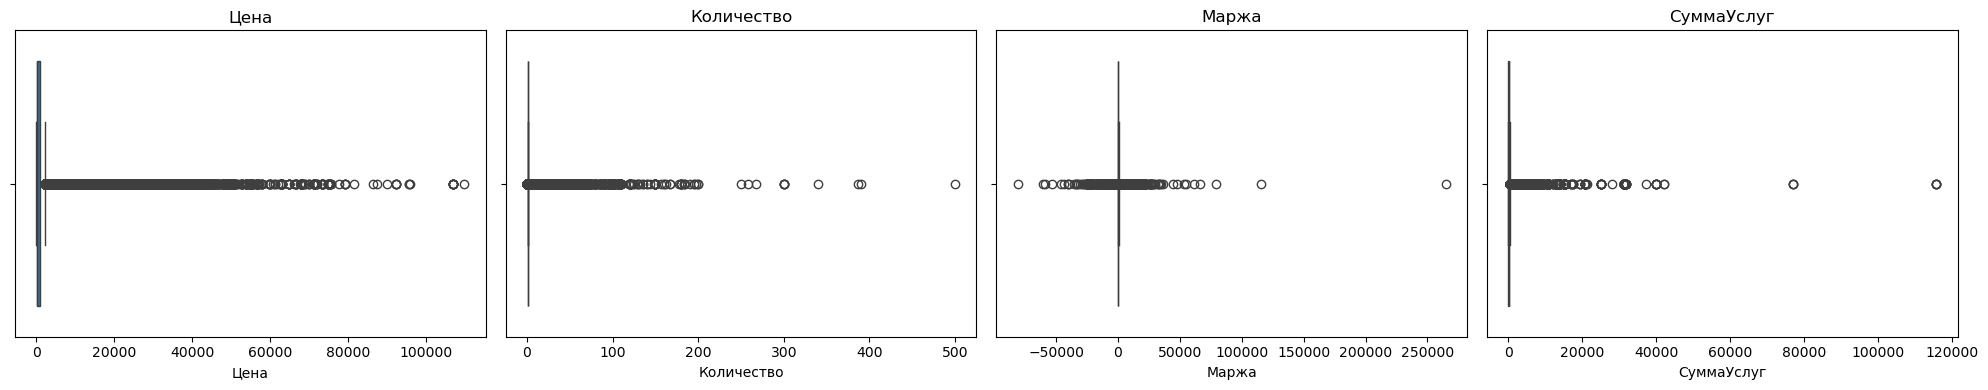

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, ['Цена', 'Количество', 'Маржа', 'СуммаУслуг']):
    sns.boxplot(x=df_clean[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [16]:
df_clean = df_clean[
    (df_clean['Цена'] <= 90000) &
    (df_clean['Количество'] <= 250) &
    (df_clean['Маржа'] <= 100000) &
    (df_clean['СуммаУслуг'] <= 60000)
]
print(f"После удаления выбросов: {df_clean.shape}")

После удаления выбросов: (4066376, 17)


In [17]:
# Удаление строк с телефоном '0'
df_clean = df_clean[df_clean['Телефон_new'] != '0']
print(f"После удаления телефона '0': {df_clean.shape}")

После удаления телефона '0': (4050261, 17)


## Сохранение очищенных транзакций

In [18]:
df_clean.to_csv('../data/children_products/children_product_cleaned_full_year.csv', index=False, encoding='utf-8-sig')
print(f"Сохранено: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок")

Сохранено: 4050261 строк, 17 колонок


## Построение клиентского витрины (showcase)

In [19]:
def create_customer_showcase(df):
    df['СуммаСтроки'] = df['Цена'] * df['Количество']
    df['МаржаСтроки'] = df['Маржа'] * df['Количество']

    showcase = pd.DataFrame({'phone': df['Телефон_new'].unique()})

    is_not_cancelled = df['Отменено'] == 'Нет'
    is_delivered = df['Статус'] == 'Доставлен'

    df_success = df[is_delivered & is_not_cancelled].copy()
    df_all = df.copy()

    # Агрегация по заказам (доставленные)
    orders_agg = df_success.groupby(['Телефон_new', 'НомерЗаказаНаСайте'], as_index=False).agg({
        'СуммаСтроки': 'sum',
        'МаржаСтроки': 'sum',
        'Количество': 'sum',
        'Цена': 'count'
    }).rename(columns={
        'СуммаСтроки': 'OrderSum',
        'МаржаСтроки': 'OrderMargin',
        'Количество': 'OrderQty',
        'Цена': 'OrderItemsCount'
    })

    metrics = orders_agg.groupby('Телефон_new').agg(
        ОбщаяСуммаЗаказов=('OrderSum', 'sum'),
        СредняяСуммаЗаказов=('OrderSum', 'mean'),
        ОбщаяМаржаЗаказов=('OrderMargin', 'sum'),
        СредняяМаржаЗаказов=('OrderMargin', 'mean'),
        КоличествоТоварныхПозиций=('OrderItemsCount', 'mean')
    ).reset_index().rename(columns={'Телефон_new': 'phone'})

    showcase = showcase.merge(metrics, on='phone', how='left')

    # Статистика по заказам (все заказы)
    order_statuses = df_all.sort_values('НомерЗаказаНаСайте').drop_duplicates('НомерЗаказаНаСайте')

    agg_dict = {
        'НомерЗаказаНаСайте': 'nunique',
        'Отменено': lambda x: (x == 'Да').mean(),
        'Статус': lambda x: (x == 'Доставлен').mean()
    }

    metrics = order_statuses.groupby('Телефон_new').agg(agg_dict).reset_index()
    metrics.rename(columns={
        'Телефон_new': 'phone',
        'НомерЗаказаНаСайте': 'КоличествоЗаказов',
        'Отменено': 'ДоляОтменненыхЗаказов',
        'Статус': 'ДоляДоставленныхЗаказов'
    }, inplace=True)

    showcase = showcase.merge(metrics, on='phone', how='left')

    # Товарные позиции
    i_metrics = df_success.groupby('Телефон_new').agg(
        Количество=('Количество', 'sum'),
        ID_SKU=('ID_SKU', 'nunique')
    ).reset_index().rename(columns={
        'Телефон_new': 'phone',
        'Количество': 'ОбщееКоличествоТоваров',
        'ID_SKU': 'КоличествоУникальныхТоваров'
    })
    showcase = showcase.merge(i_metrics, on='phone', how='left')

    # Суммы услуг
    s_metrics = df_success.groupby('Телефон_new')['СуммаУслуг'].agg(['sum', 'mean']).reset_index()
    s_metrics.columns = ['phone', 'ОбщаяСуммаУслуг', 'СредняяСуммаУслуг']
    showcase = showcase.merge(s_metrics, on='phone', how='left')

    # Уникальные категории
    c_metrics = df_success.groupby('Телефон_new').agg(
        Группа2=('Группа2', 'nunique'),
        Группа3=('Группа3', 'nunique')
    ).reset_index().rename(columns={
        'Телефон_new': 'phone',
        'Группа2': 'КоличествоУникальныхТоваровГруппы2',
        'Группа3': 'КоличествоУникальныхТоваровГруппы3'
    })
    showcase = showcase.merge(c_metrics, on='phone', how='left')

    # Распределение категорий (доли)
    for col_name in ['Группа2', 'Группа3', 'Тип', 'МетодДоставки_Групп', 'Гео']:
        shares = (pd.crosstab(df_success['Телефон_new'], df_success[col_name], normalize='index')
                   .add_prefix(f'{col_name}_')
                   .reset_index()
                   .rename(columns={'Телефон_new': 'phone'}))
        showcase = showcase.merge(shares, on='phone', how='left')

    return showcase.fillna(0)

In [20]:
df_new = pd.read_csv('../data/children_products/children_product_cleaned_full_year.csv', encoding='utf-8-sig')
showcase = create_customer_showcase(df_new)

print(f"Клиентов: {len(showcase)}")
print(f"Признаков: {len(showcase.columns)}")
print(showcase.head())

/var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/ipykernel_95557/804551758.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('../data/children_products/children_product_cleaned_full_year.csv', encoding='utf-8-sig')


Клиентов: 421712
Признаков: 137
                     phone  ОбщаяСуммаЗаказов  СредняяСуммаЗаказов  \
0  55575454-49504949555170                0.0             0.000000   
1  55574851-55555555555176             3585.0          3585.000000   
2  55575054-56575354545171            12500.0          1785.714286   
3  55575149-50524951545076             1069.0          1069.000000   
4  55575054-49555657564875            13716.0         13716.000000   

   ОбщаяМаржаЗаказов  СредняяМаржаЗаказов  КоличествоТоварныхПозиций  \
0               0.00                 0.00                   0.000000   
1             366.75               366.75                   1.000000   
2            1386.35               198.05                   2.571429   
3              83.97                83.97                   1.000000   
4            1327.62              1327.62                   2.000000   

   КоличествоЗаказов  ДоляОтменненыхЗаказов  ДоляДоставленныхЗаказов  \
0               18.0               0.05555

In [21]:
showcase.to_csv('../data/children_products/children_product_showcase_full_year.csv', index=False, encoding='utf-8-sig')
showcase.head(100).to_excel('../data/children_products/children_product_showcase_full_year_example.xlsx', index=False)

## Анализ корреляций и удаление скоррелированных признаков

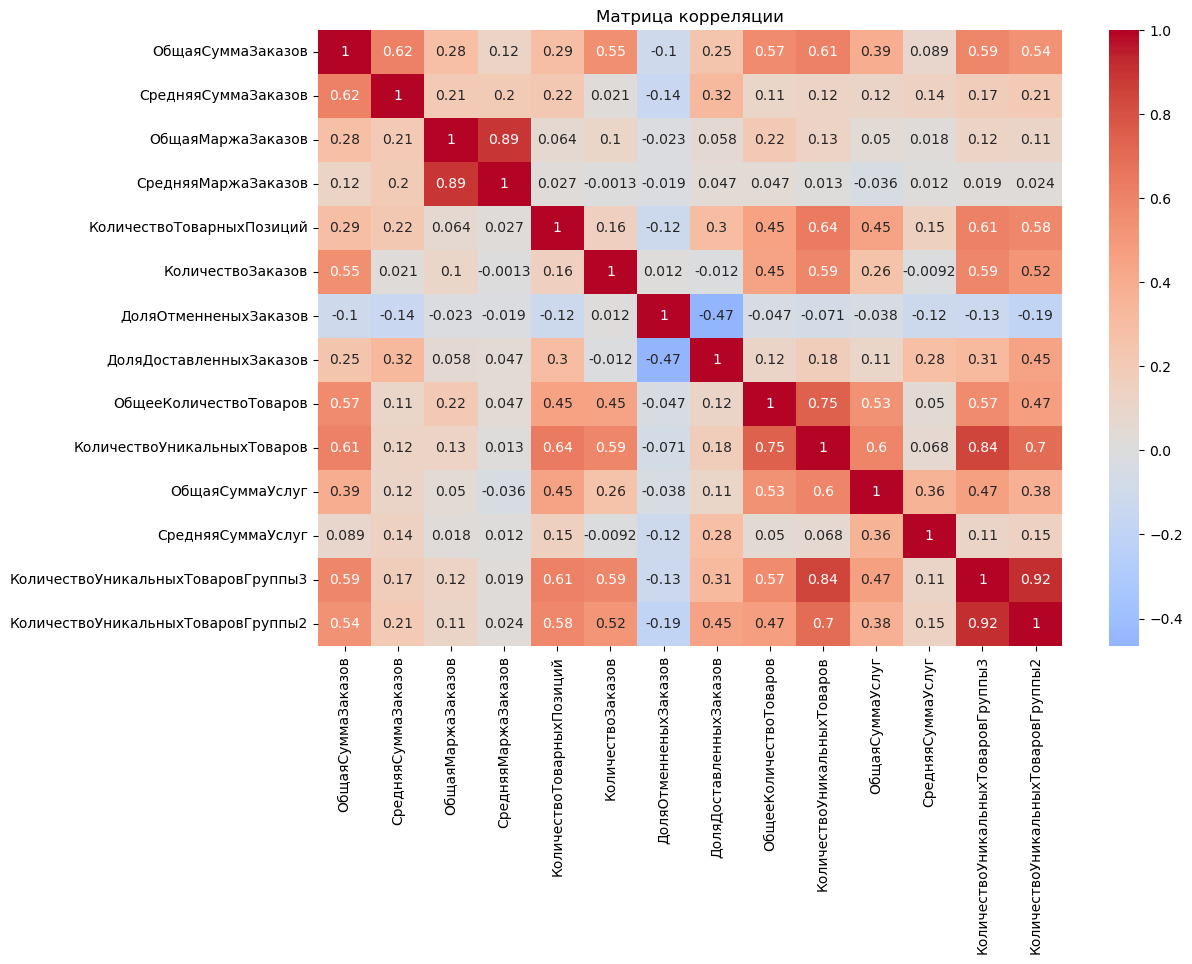

In [22]:
columns_to_check = [
    'ОбщаяСуммаЗаказов',
    'СредняяСуммаЗаказов',
    'ОбщаяМаржаЗаказов',
    'СредняяМаржаЗаказов',
    'КоличествоТоварныхПозиций',
    'КоличествоЗаказов',
    'ДоляОтменненыхЗаказов',
    'ДоляДоставленныхЗаказов',
    'ОбщееКоличествоТоваров',
    'КоличествоУникальныхТоваров',
    'ОбщаяСуммаУслуг',
    'СредняяСуммаУслуг',
    'КоличествоУникальныхТоваровГруппы3',
    'КоличествоУникальныхТоваровГруппы2'
]
df_selected = showcase[columns_to_check]
correlation_matrix = df_selected.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляции')
plt.show()

In [23]:
# Удаление высококоррелированных признаков (аналогично оригинальному ноутбуку)
showcase = showcase.drop(
    [
        'ОбщаяСуммаЗаказов',
        'ОбщаяМаржаЗаказов',
        'КоличествоУникальныхТоваровГруппы3',
        'КоличествоУникальныхТоваровГруппы2'
     ],
    axis=1)

print(f"Признаков после удаления коррелированных: {len(showcase.columns)}")

Признаков после удаления коррелированных: 133


In [24]:
# Удаление клиентов с нулевой средней суммой заказов
print(f"Клиентов с нулевой средней суммой: {showcase[showcase['СредняяСуммаЗаказов'] == 0].shape[0]}")
showcase = showcase[showcase['СредняяСуммаЗаказов'] != 0]
print(f"Итого клиентов: {len(showcase)}, признаков: {len(showcase.columns)}")

Клиентов с нулевой средней суммой: 100450
Итого клиентов: 321262, признаков: 133


In [25]:
showcase.to_csv('../data/children_products/children_product_showcase_full_year_remove_corr.csv', index=False, encoding='utf-8-sig')
showcase.head(100).to_excel('../data/children_products/children_product_showcase_full_year_example.xlsx', index=False)
print(f"Финальный датасет: {showcase.shape}")

Финальный датасет: (321262, 133)
